In [1]:
from matplotlib import pyplot as plt
import numpy as np
from astropy.io import fits
import healpy as hp
from healpy.newvisufunc import projview, newprojplot
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
import astropy.units as u
from scipy.ndimage import map_coordinates
from reproject import reproject_to_healpix

In [2]:
from matplotlib.colors import LogNorm
from matplotlib.colors import SymLogNorm

In [3]:
NSIDE = 276 


In [4]:
fn = '/home/justin/ResearchSummer26/WHAM/wham-ss-DR1-v161116-170912-grid.fits'
whamDat = fits.getdata(fn)
whamHdr = fits.getheader(fn)

In [5]:
whamHdr

 [astropy.io.fits.verify]


SIMPLE  =                    T /  Written by IDL:  Tue Sep 12 13:28:51 2017     
BITPIX  =                  -32 / Real*4 (floating point)                        
NAXIS   =                    3 /                                                
NAXIS1  =                 1440 /                                                
NAXIS2  =                  720 /                                                
NAXIS3  =                  162 /                                                
EXTEND  =                    T / Extensions may be present                      
DATE    = '2017-09-12'         /                                                
TAG     = 'DR1     '           / General release tag                            
VERSION = '161116  '           / Generated from wham-ss-161116.sav              
OBJECT  = 'WHAM Sky Survey - Release DR1 (161116)' /                            
RESTWAV =          6.56300E-07 / Rest wavelength of H-alpha [m]                 
BSCALE  =              1.000

In [6]:
integratedHa = np.nansum(whamDat[-30000:30000,:,:], axis = 0)
wcs2d = WCS(whamHdr).celestial

In [7]:
targetNside = 128
coordsys = 'G'

In [8]:
targetNside = 128 
coordsys = 'G'
whamHealpix, footprint = reproject_to_healpix(
    (integratedHa, wcs2d), 
    coord_system_out = coordsys, 
    nside=targetNside, 
    order = 'bilinear'
)

In [9]:
whamHealpix[np.isnan(whamHealpix)] = hp.UNSEEN

In [10]:
hp.write_map(
    "wham_ha_integrated.hpx.fits",
    whamHealpix, 
    coord = 'G', 
    overwrite = True
)

setting the output map dtype to [dtype('float32')]


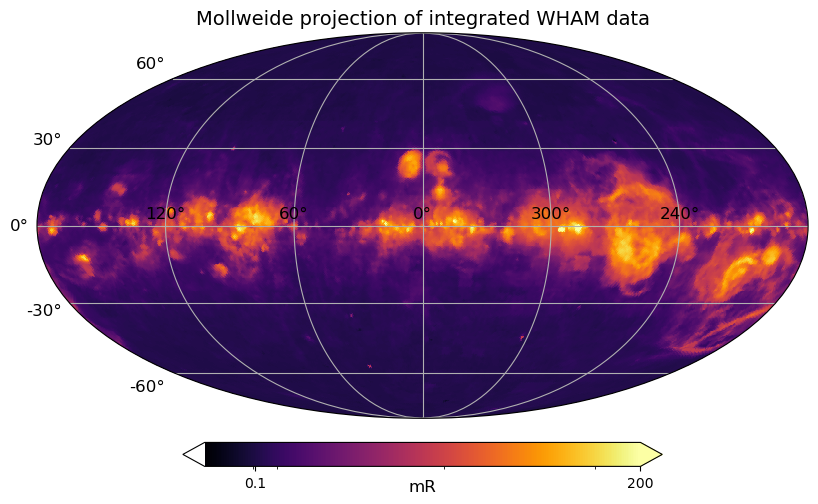

In [11]:
projview(
    whamHealpix, 
    projection_type = 'mollweide', 
    graticule = True, 
    graticule_labels=True, 
    cb_orientation = 'horizontal', 
    cmap = 'inferno', 
    min = 0.1, 
    max = 200, 
    unit = 'mR', 
    title = 'Mollweide projection of integrated WHAM data',
    norm = SymLogNorm(vmin = -2, vmax = 200, linthresh = 7)
)

In [12]:
fn = '~/ResearchSummer26/DRAGONS/DRAGONS_faraday_depth_cubes/faraday_synthesis/dragons_Npeaks_8sigma.hpx.fits'
NpeaksDat = fits.getdata(fn) 
NpeaksHdr = fits.getheader(fn)

In [13]:
import matplotlib.colors as mcolors
original_cmap = plt.get_cmap('Set1')

colors = original_cmap(np.arange(1,6,1))
Set11 = mcolors.ListedColormap(colors)

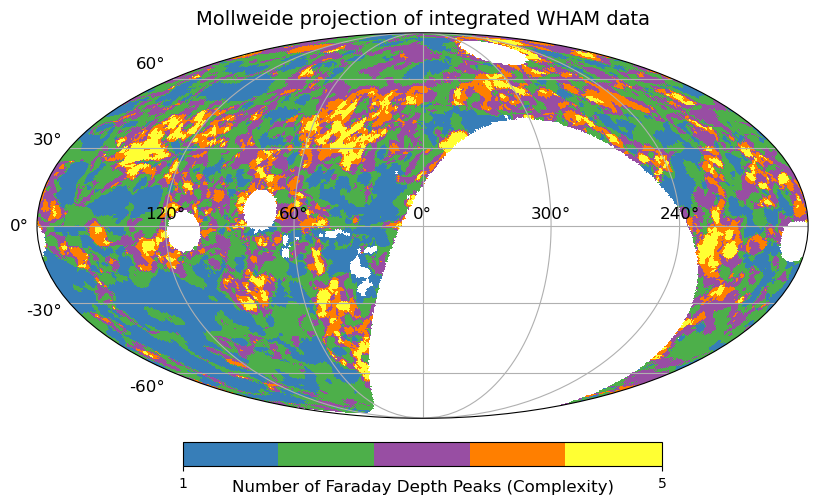

In [14]:
projview(
    NpeaksDat, 
    projection_type = 'mollweide', 
    graticule = True, 
    graticule_labels=True, 
    cb_orientation = 'horizontal', 
    cmap = Set11, 
    min = 1, 
    max = 5, 
    unit = 'Number of Faraday Depth Peaks (Complexity)', 
    title = 'Mollweide projection of integrated WHAM data',
)

In [15]:
NpeaksHdr

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -64 / array data type                                
NAXIS   =                    1 / number of array dimensions                     
NAXIS1  =               196608                                                  
PIXTYPE = 'HEALPIX '           / HEALPIX pixelisation                           
ORDERING= 'RING    '           / Pixel ordering scheme, either RING or NESTED   
NSIDE   =                  128 / Resolution parameter of HEALPIX                
INDXSCHM= 'IMPLICIT'           / Indexing: IMPLICIT or EXPLICIT                 
OBJECT  = 'FULLSKY '           / Sky coverage, either FULLSKY or PARTIAL        
BUNIT   = 'NUMBER  '                                                            
DATE    = '2025-09-15'                                                          
INSTRUME= 'DRAO-15 '                                                            

In [16]:
fwhmSmoothRad = np.radians(np.sqrt(3.6**2 - 1.0**2))
whamSmoothed = hp.smoothing(whamHealpix, fwhm=fwhmSmoothRad)
NpeaksDatRounded = np.round(NpeaksDat).astype(float)
validMask = ((whamSmoothed != hp.UNSEEN) & 
             (NpeaksDat != hp.UNSEEN) & 
             (~np.isnan(whamSmoothed)) & 
             (~np.isnan(NpeaksDat)) & 
             (NpeaksDatRounded >=1)
             
)

haIntensities = whamSmoothed[validMask]
peakCounts  = NpeaksDat[validMask].astype(int)

In [17]:
pixelAreaDeg2 = hp.nside2pixarea(targetNside, degrees = True)
uniquePeaks = np.arange(0,9)
binnedHaMedians = []
binnedHaStd = []
binnedHaMedianErrors = []
binnedHaMeans = []
binnedHaMeanErrors = []
beamFWHMdeg = 3.6 
beamArea2 = 1.133 * (beamFWHMdeg**2)
for numPeaks in uniquePeaks: 
    haInBin = haIntensities[peakCounts == numPeaks]
    nPixels = len(haInBin)
    if nPixels > 0: 
        medianVal = np.median(haInBin)
        stdVal = np.std(haInBin)
        meanVal = np.mean(haInBin)
        nIndependentBeams = (nPixels * pixelAreaDeg2) / beamArea2
        if nIndependentBeams < 1: 
            nIndependentBeams = 1.0

        seMean = stdVal / np.sqrt(nIndependentBeams)
        seMedian = 1.273 * (stdVal / np.sqrt(nIndependentBeams))
        
        print(f"Peaks: {numPeaks} | Pixels: {len(haInBin):>7} | Median: {medianVal} | standard deviation: {stdVal}")
    else: 
        medianVal = np.nan 
        stdVal = np.nan
        print(f"Peaks: {numPeaks} | Pixels: 0 | bad data")
    binnedHaMeans.append(meanVal)
    binnedHaMedians.append(medianVal)
    binnedHaStd.append(stdVal)
    binnedHaMedianErrors.append(seMedian)
    binnedHaMeanErrors.append(seMean)

Peaks: 0 | Pixels:     106 | Median: 0.2843470263796377 | standard deviation: 0.5708235682729286
Peaks: 1 | Pixels:   34436 | Median: 0.8272337419909808 | standard deviation: 5.1227436680906155
Peaks: 2 | Pixels:   46859 | Median: 0.636995190794813 | standard deviation: 5.4488232423759
Peaks: 3 | Pixels:   30883 | Median: 0.7597199215355994 | standard deviation: 5.334623357227899
Peaks: 4 | Pixels:   12496 | Median: 0.7319138741970745 | standard deviation: 5.595800116821228
Peaks: 5 | Pixels:    3017 | Median: 0.7201129861938869 | standard deviation: 4.752881537369828
Peaks: 6 | Pixels:     670 | Median: 0.7653710472870381 | standard deviation: 2.353440173235091
Peaks: 7 | Pixels:     103 | Median: 1.016968148108464 | standard deviation: 1.6317319398214554
Peaks: 8 | Pixels:       1 | Median: 1.8464894143428232 | standard deviation: 0.0


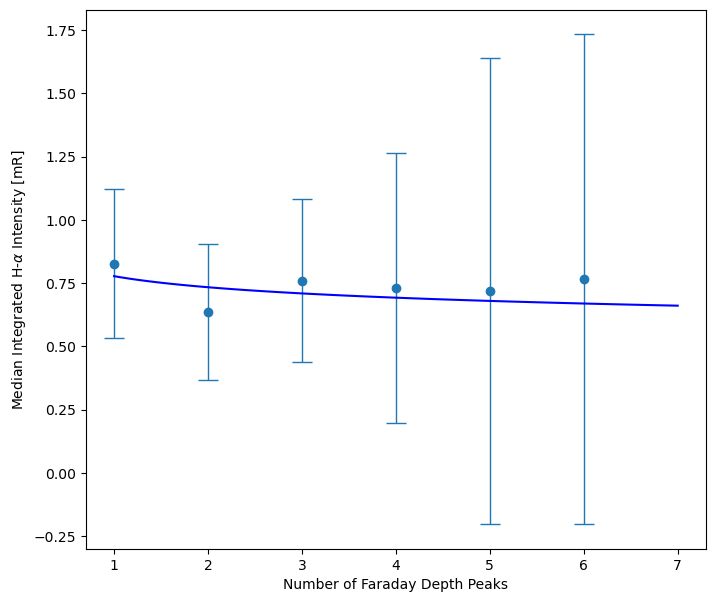

Text(0, 0.5, 'Mean of Integrated H-$\\alpha$ Intensity [mR]')

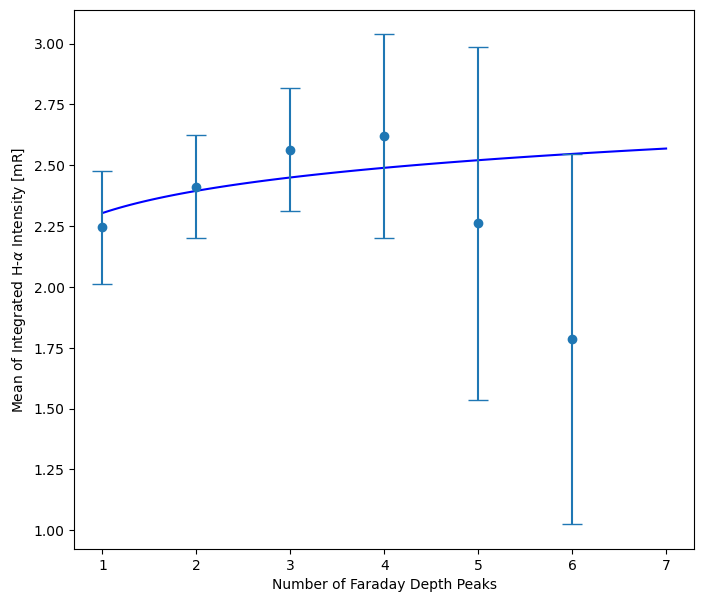

In [18]:
from scipy.optimize import curve_fit

def powerLawModel(x, a, k): 
    return a * (x**k)

validBinnedHaMeans = binnedHaMeans[1:7]
validUniquePeaks = uniquePeaks[1:7]
validBinnedHaMedians = binnedHaMedians[1:7]
validBinnedHaMedianErrors = binnedHaMedianErrors[1:7]
validBinnedHaMeanErrors = binnedHaMeanErrors[1:7]

poptPow, pPowCov = curve_fit(powerLawModel, validUniquePeaks, validBinnedHaMedians, p0=[1.0, 1.0], sigma = validBinnedHaMedianErrors)
xFine = np.linspace(1, 7, 100)

plt.figure(figsize=(8,7))
plt.errorbar(validUniquePeaks, validBinnedHaMedians, yerr=validBinnedHaMedianErrors, fmt='o', capsize = 7, elinewidth = 1)
plt.plot(xFine, powerLawModel(xFine, *poptPow), 'b-', label = f'Power-Law fit')
plt.xlabel("Number of Faraday Depth Peaks") 
plt.ylabel(r"Median Integrated H-$\alpha$ Intensity [mR]")
plt.show()

poptPow2, pPowCov2 = curve_fit(powerLawModel, validUniquePeaks, validBinnedHaMeans, p0=(1.0,1.0), sigma = validBinnedHaMeanErrors)

plt.figure(figsize=(8,7))
plt.plot(xFine, powerLawModel(xFine, *poptPow2), 'b-')
plt.errorbar(validUniquePeaks, validBinnedHaMeans, yerr = validBinnedHaMeanErrors, fmt = 'o', capsize = 7)
plt.xlabel('Number of Faraday Depth Peaks') 
plt.ylabel(r"Mean of Integrated H-$\alpha$ Intensity [mR]")

In [19]:
#I don't see anything, but I might as well do a spearman 
from scipy.stats import spearmanr


rawHaPixels = whamSmoothed[validMask]
rawPeaksPixels = NpeaksDat[validMask]

#spearman tests
spearmanResult = spearmanr(rawHaPixels, rawPeaksPixels)
rhoValue = spearmanResult.statistic
pValue = spearmanResult.pvalue

print("--- Spearman Rank Correlation Results ---")
print(f"Correlation Coefficient (rho): {rhoValue:.4f}")
print(f"Statistical Significance (p-value): {pValue:.4e}")




--- Spearman Rank Correlation Results ---
Correlation Coefficient (rho): 0.0468
Statistical Significance (p-value): 2.7051e-63


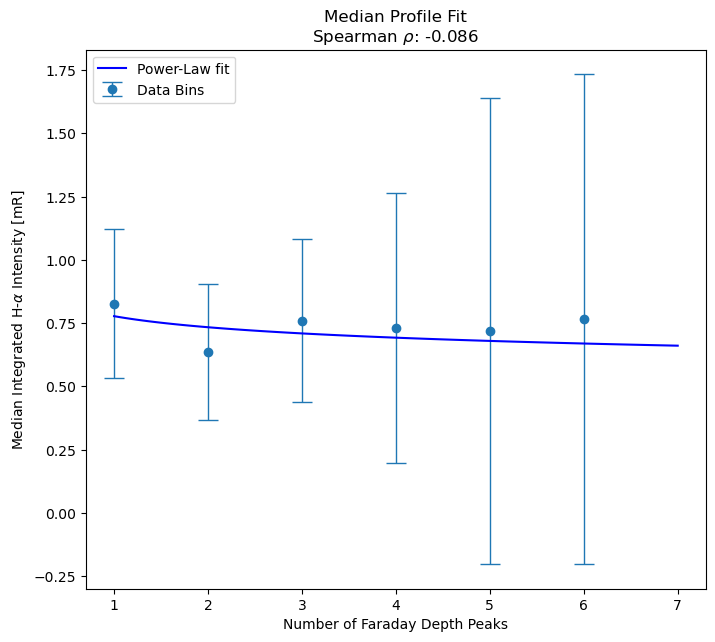

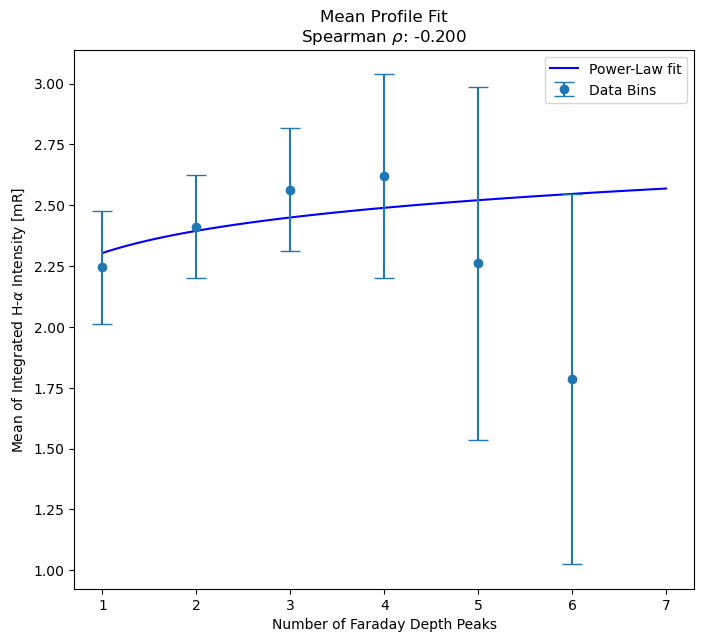

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import spearmanr


def powerLawModel(x, a, k): 
    return a * (x**k)

validBinnedHaMeans = binnedHaMeans[1:7]
validUniquePeaks = uniquePeaks[1:7]
validBinnedHaMedians = binnedHaMedians[1:7]
validBinnedHaMedianErrors = binnedHaMedianErrors[1:7]
validBinnedHaMeanErrors = binnedHaMeanErrors[1:7]

#calculating spearman stats
rawHaPixels = whamSmoothed[validMask]
rawPeaksPixels = NpeaksDat[validMask]
spearmanResult = spearmanr(rawHaPixels, rawPeaksPixels)
rhoValue = spearmanResult.statistic
pValue = spearmanResult.pvalue

spearmanMedianRes = spearmanr(validBinnedHaMedians, validUniquePeaks)
spearmanMeanRes = spearmanr(validBinnedHaMeans, validUniquePeaks) 
meanRho = spearmanMeanRes.statistic 
medianRho = spearmanMedianRes.statistic

#plotting medians with a power law
def powerLawModel(x, a, k): 
    return a * (x**k)
poptPow, pPowCov = curve_fit(powerLawModel, validUniquePeaks, validBinnedHaMedians, p0=[1.0, 1.0], sigma=validBinnedHaMedianErrors)
xFine = np.linspace(1, 7, 100)

plt.figure(figsize=(8,7))
plt.errorbar(validUniquePeaks, validBinnedHaMedians, yerr=validBinnedHaMedianErrors, fmt='o', capsize=7, elinewidth=1, label='Data Bins')
plt.plot(xFine, powerLawModel(xFine, *poptPow), 'b-', label='Power-Law fit')
plt.xlabel("Number of Faraday Depth Peaks") 
plt.ylabel(r"Median Integrated H-$\alpha$ Intensity [mR]")
# Added stats to the title for posterityROG-Zephyrus-G16-GU603VV-GU603VV
plt.title(f"Median Profile Fit\nSpearman $\\rho$: {medianRho:.3f}")
plt.legend()
plt.show()

#plotting means with a power law
poptPow2, pPowCov2 = curve_fit(powerLawModel, validUniquePeaks, validBinnedHaMeans, p0=(1.0,1.0), sigma=validBinnedHaMeanErrors)

plt.figure(figsize=(8,7))
plt.plot(xFine, powerLawModel(xFine, *poptPow2), 'b-', label='Power-Law fit')
plt.errorbar(validUniquePeaks, validBinnedHaMeans, yerr=validBinnedHaMeanErrors, fmt='o', capsize=7, label='Data Bins')
plt.xlabel('Number of Faraday Depth Peaks') 
plt.ylabel(r"Mean of Integrated H-$\alpha$ Intensity [mR]")
plt.title(f"Mean Profile Fit\nSpearman $\\rho$: {meanRho:.3f}")
plt.legend()
plt.show()


In [21]:
whamHdr

SIMPLE  =                    T /  Written by IDL:  Tue Sep 12 13:28:51 2017     
BITPIX  =                  -32 / Real*4 (floating point)                        
NAXIS   =                    3 /                                                
NAXIS1  =                 1440 /                                                
NAXIS2  =                  720 /                                                
NAXIS3  =                  162 /                                                
EXTEND  =                    T / Extensions may be present                      
DATE    = '2017-09-12'         /                                                
TAG     = 'DR1     '           / General release tag                            
VERSION = '161116  '           / Generated from wham-ss-161116.sav              
OBJECT  = 'WHAM Sky Survey - Release DR1 (161116)' /                            
RESTWAV =          6.56300E-07 / Rest wavelength of H-alpha [m]                 
BSCALE  =              1.000

In [22]:
rawPeaks = NpeaksDat[validMask]
print(f"rawHa NaNs: {np.sum(np.isnan(rawHa))}")
print(f"rawPeaks NaNs: {np.sum(np.isnan(rawPeaks))}")
print(f"rawHa infs: {np.sum(np.isinf(rawHa))}")
print(f"rawPeaks infs: {np.sum(np.isinf(rawPeaks))}")

NameError: name 'rawHa' is not defined

Orthogonal Distance Regression fits:
Amplitude (a): 2.1785 +/- 0.0271
Power Index (k): 0.1295 +/- 0.0129


Text(0.5, 1.0, 'All Aligned Sky Pixels: faraday Complexity vs. H-$\\alpha$ Intensity')

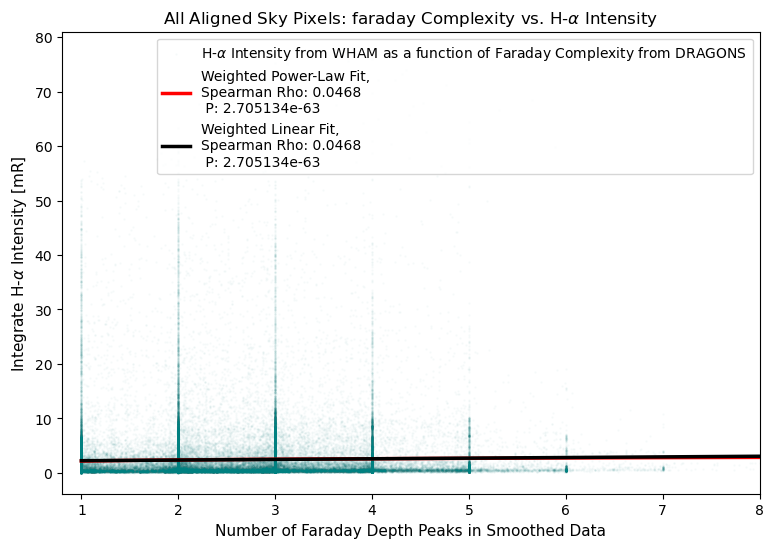

In [24]:
from scipy.odr import ODR, Model, RealData

rawHa = whamSmoothed[validMask] 
rawPeaks = NpeaksDat[validMask] 

spearmanResHaPeaks = spearmanr(rawHa, rawPeaks)
HaPeaksRho = spearmanResHaPeaks.statistic 
HaPeaksP = spearmanResHaPeaks.pvalue

def powerLawOdr(p, x): 
    return p[0] * (x**p[1])

def linearOdr(m, x): 
    return m[0] + m[1]*x 

sigmaX = np.full(shape=rawHa.shape, fill_value = 50.0)
sigmaY = np.full(shape=rawPeaks.shape, fill_value = 0.011)

odrModel1 = Model(powerLawOdr)
odrModel2 = Model(linearOdr) 
odrData = RealData(y=rawHa, x = rawPeaks, sx=sigmaY, sy=sigmaX)

odrInstance1 = ODR(odrData, odrModel1,  beta0=[1.0, 1.0])
odrOutput1 = odrInstance1.run()
odrInstance2 = ODR(odrData, odrModel2, beta0=[1.0,1.0])
odrOutput2 = odrInstance2.run()

bestA1, bestK1 = odrOutput1.beta 
errorA1, errorK1 = odrOutput1.sd_beta 
bestA2, bestK2 = odrOutput2.beta 
errorA2, errorK2 = odrOutput2.sd_beta

print("Orthogonal Distance Regression fits:") 
print(f"Amplitude (a): {bestA1:.4f} +/- {errorA1:.4f}")
print(f"Power Index (k): {bestK1:.4f} +/- {errorK1:.4f}")

# poptPow, pPowCov = curve_fit(powerLawModel, rawPeaks, rawHa, p0=[1.0, 1.0], sigma=np.full(shape=rawPeaks,shape, fill_value=0.011))
xFine = np.linspace(max(np.min(rawPeaks),1e-6), (np.max(rawPeaks)))
yfit1 = powerLawOdr([bestA1, bestK1], xFine)
yfit2 = linearOdr([bestA2, bestK2], xFine)
plt.figure(figsize  =(9,6))

plt.scatter( 
    rawPeaks,
    rawHa,
    alpha = 0.02, 
    c='teal', 
    s = 1, 
    rasterized=True,
    label = r"H-$\alpha$ Intensity from WHAM as a function of Faraday Complexity from DRAGONS"
)
plt.plot(xFine, 
         yfit1, 
         color = 'red', 
         linewidth = 2.5, 
         linestyle = '-', 
         label=f"Weighted Power-Law Fit, \nSpearman Rho: {HaPeaksRho:.4f} \n P: {HaPeaksP:4e}"
        )
plt.plot(xFine, 
         yfit2, 
         color = 'black', 
         linewidth = 2.5, 
         linestyle = '-', 
         label=f"Weighted Linear Fit, \nSpearman Rho: {HaPeaksRho:.4f} \n P: {HaPeaksP:4e}"
        )
plt.legend()
plt.xlim(0.8, 8)
plt.ylabel(r"Integrate H-$\alpha$ Intensity [mR]", fontsize = 11)
plt.xlabel("Number of Faraday Depth Peaks in Smoothed Data", fontsize = 11)
plt.title(r"All Aligned Sky Pixels: faraday Complexity vs. H-$\alpha$ Intensity")

Orthogonal Distance Regression fits:
Amplitude (a): 2.1995 +/- 0.0267
Power Index (k): 0.1184 +/- 0.0126


Text(0.5, 1.0, 'All Aligned Sky Pixels: faraday Complexity vs. H-$\\alpha$ Intensity')

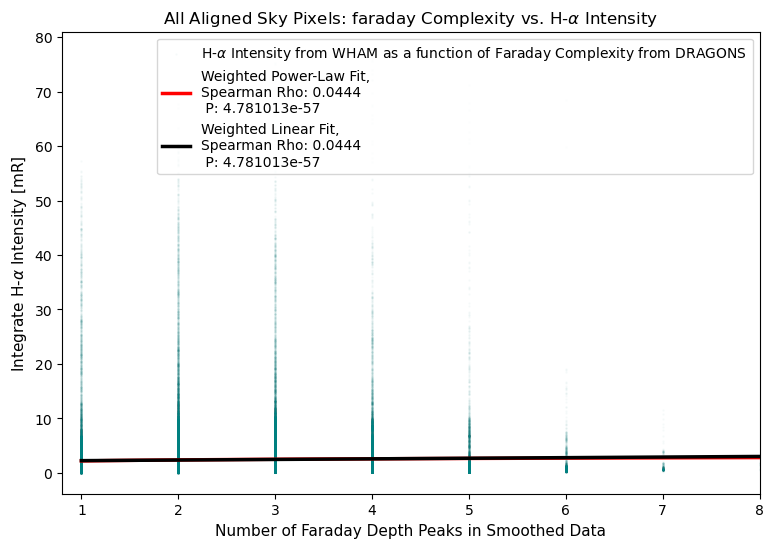

In [25]:
from scipy.odr import ODR, Model, RealData

rawHa = whamSmoothed[validMask] 
rawPeaks = NpeaksDatRounded[validMask] 

spearmanResHaPeaks = spearmanr(rawHa, rawPeaks)
HaPeaksRho = spearmanResHaPeaks.statistic 
HaPeaksP = spearmanResHaPeaks.pvalue

def powerLawOdr(p, x): 
    return p[0] * (x**p[1])

def linearOdr(m, x): 
    return m[0] + m[1]*x 

sigmaX = np.full(shape=rawHa.shape, fill_value = 50.0)
sigmaY = np.full(shape=rawPeaks.shape, fill_value = 0.011)

odrModel1 = Model(powerLawOdr)
odrModel2 = Model(linearOdr) 
odrData = RealData(y=rawHa, x = rawPeaks, sx=sigmaY, sy=sigmaX)

odrInstance1 = ODR(odrData, odrModel1,  beta0=[1.0, 1.0])
odrOutput1 = odrInstance1.run()
odrInstance2 = ODR(odrData, odrModel2, beta0=[1.0,1.0])
odrOutput2 = odrInstance2.run()

bestA1, bestK1 = odrOutput1.beta 
errorA1, errorK1 = odrOutput1.sd_beta 
bestA2, bestK2 = odrOutput2.beta 
errorA2, errorK2 = odrOutput2.sd_beta

print("Orthogonal Distance Regression fits:") 
print(f"Amplitude (a): {bestA1:.4f} +/- {errorA1:.4f}")
print(f"Power Index (k): {bestK1:.4f} +/- {errorK1:.4f}")

# poptPow, pPowCov = curve_fit(powerLawModel, rawPeaks, rawHa, p0=[1.0, 1.0], sigma=np.full(shape=rawPeaks,shape, fill_value=0.011))
xFine = np.linspace(max(np.min(rawPeaks),1e-6), (np.max(rawPeaks)))
yfit1 = powerLawOdr([bestA1, bestK1], xFine)
yfit2 = linearOdr([bestA2, bestK2], xFine)
plt.figure(figsize  =(9,6))

plt.scatter( 
    rawPeaks,
    rawHa,
    alpha = 0.02, 
    c='teal', 
    s = 1, 
    rasterized=True,
    label = r"H-$\alpha$ Intensity from WHAM as a function of Faraday Complexity from DRAGONS"
)
plt.plot(xFine, 
         yfit1, 
         color = 'red', 
         linewidth = 2.5, 
         linestyle = '-', 
         label=f"Weighted Power-Law Fit, \nSpearman Rho: {HaPeaksRho:.4f} \n P: {HaPeaksP:4e}"
        )
plt.plot(xFine, 
         yfit2, 
         color = 'black', 
         linewidth = 2.5, 
         linestyle = '-', 
         label=f"Weighted Linear Fit, \nSpearman Rho: {HaPeaksRho:.4f} \n P: {HaPeaksP:4e}"
        )
plt.legend()
plt.xlim(0.8, 8)
plt.ylabel(r"Integrate H-$\alpha$ Intensity [mR]", fontsize = 11)
plt.xlabel("Number of Faraday Depth Peaks in Smoothed Data", fontsize = 11)
plt.title(r"All Aligned Sky Pixels: faraday Complexity vs. H-$\alpha$ Intensity")

/tmp/ipykernel_43299/3021461889.py:11: RuntimeWarning: invalid value encountered in power
  return p[0] * (x**p[1])


Orthogonal Distance Regression fits:
Amplitude (a): 1.0018 +/- 0.0202
Power Index (k): 1.0714 +/- 0.0180


Text(0.5, 1.0, 'All Aligned Sky Pixels: faraday Complexity vs. H-$\\alpha$ Intensity')

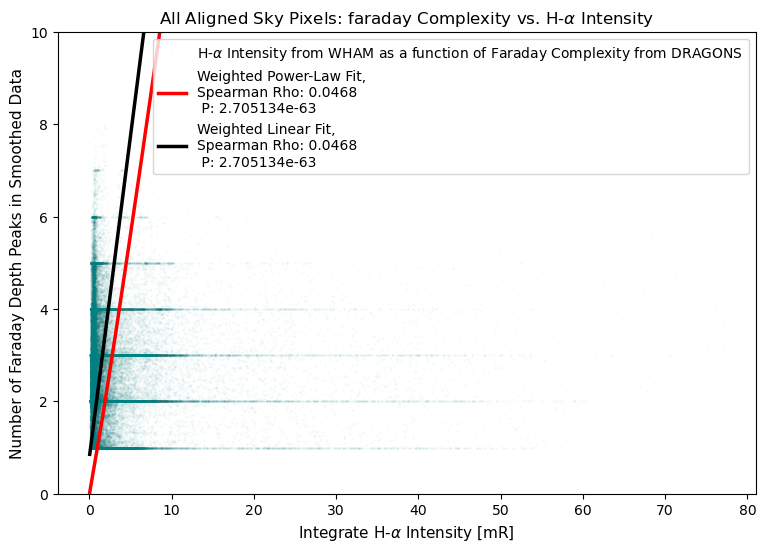

In [26]:
from scipy.odr import ODR, Model, RealData

rawHa = whamSmoothed[validMask] 
rawPeaks = NpeaksDat[validMask] 

spearmanResHaPeaks = spearmanr(rawPeaks, rawHa)
HaPeaksRho = spearmanResHaPeaks.statistic 
HaPeaksP = spearmanResHaPeaks.pvalue

def powerLawOdr(p, x): 
    return p[0] * (x**p[1])
def linearOdr(m, x):
    return m[0] + m[1]*x
sigmaHa = np.full(shape=rawHa.shape, fill_value = 50.0)
sigmaPeaks = np.full(shape=rawPeaks.shape, fill_value = 0.011)

odrModel1 = Model(powerLawOdr) 
odrModel2 = Model(linearOdr)
odrData = RealData(x=rawHa, y = rawPeaks, sx=sigmaX, sy=sigmaY)

odrInstance1 = ODR(odrData, odrModel1,  beta0=[1.0, 1.0])
odrOutput1 = odrInstance1.run()
odrInstance2 = ODR(odrData, odrModel2, beta0=[1.0,1.0])
odrOutput2 = odrInstance2.run()


bestA1, bestK1 = odrOutput1.beta 
errorA1, errorK1 = odrOutput1.sd_beta 

bestA2, bestK2 = odrOutput2.beta 
errorA2, errorK2 = odrOutput2.sd_beta

print("Orthogonal Distance Regression fits:") 
print(f"Amplitude (a): {bestA1:.4f} +/- {errorA1:.4f}")
print(f"Power Index (k): {bestK1:.4f} +/- {errorK1:.4f}")

# poptPow, pPowCov = curve_fit(powerLawModel, rawPeaks, rawHa, p0=[1.0, 1.0], sigma=np.full(shape=rawPeaks,shape, fill_value=0.011))
xFine = np.linspace(max(np.min(rawHa),1e-6), (np.max(rawHa)))
yfit1 = powerLawOdr([bestA1, bestK1], xFine)
yfit2 = linearOdr([bestA2, bestK2], xFine)

plt.figure(figsize  =(9,6))

plt.scatter( 
    rawHa,
    rawPeaks,
    alpha = 0.02, 
    c='teal', 
    s = 1, 
    rasterized=True,
    label = r"H-$\alpha$ Intensity from WHAM as a function of Faraday Complexity from DRAGONS"
)
plt.plot(xFine, 
         yfit1, 
         color = 'red', 
         linewidth = 2.5, 
         linestyle = '-', 
         label=f"Weighted Power-Law Fit, \nSpearman Rho: {HaPeaksRho:.4f} \n P: {HaPeaksP:4e}"
        )
plt.plot(xFine, 
         yfit2, 
         color = 'black', 
         linewidth = 2.5, 
         linestyle = '-', 
         label=f"Weighted Linear Fit, \nSpearman Rho: {HaPeaksRho:.4f} \n P: {HaPeaksP:4e}"
        )

plt.legend()
plt.ylim(0, 10)
plt.xlabel(r"Integrate H-$\alpha$ Intensity [mR]", fontsize = 11)
plt.ylabel("Number of Faraday Depth Peaks in Smoothed Data", fontsize = 11)
plt.title(r"All Aligned Sky Pixels: faraday Complexity vs. H-$\alpha$ Intensity")

In [ ]:
odrOutput.pprint()

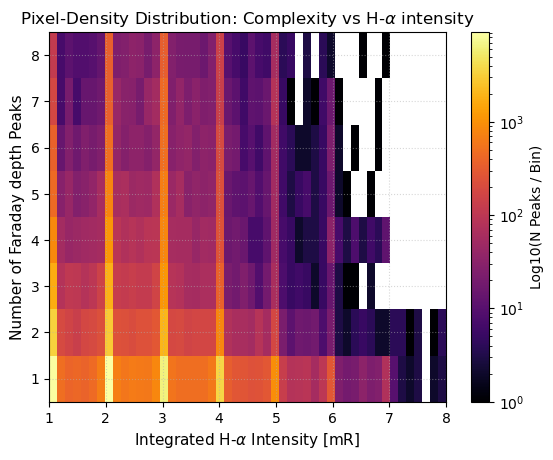

In [27]:
#2d histogram 
plt.hist2d(
    
    rawPeaks, 
    rawHa,  
    bins = [50, 8], 
    cmap = 'inferno',
    range = [[1, np.max(rawPeaks)],[0.5,8.5]],
    cmin=1, 
    norm='log'
)
cbar = plt.colorbar(label='Log10(N Peaks / Bin)')
plt.xlabel(r"Integrated H-$\alpha$ Intensity [mR]", fontsize =11)
plt.ylabel("Number of Faraday depth Peaks", fontsize=11)
plt.title(r"Pixel-Density Distribution: Complexity vs H-$\alpha$ intensity")
plt.yticks(np.arange(1,9))
plt.grid(True, linestyle=':', alpha = 0.5)


In [28]:
# Calculate how many pixels wide a 3.6 degree beam is
# For NSIDE=128, a pixel is ~0.5 degrees. A 3.6 deg beam is ~8 pixels wide.

stride = 8

independentHa = rawHaPixels[::stride]
independentPeaks = rawPeaksPixels[::stride]

strictSpearman = spearmanr(independentHa, independentPeaks)
print(f"Strict Rho: {strictSpearman.statistic:.4f}")
print(f"Strict P-Value: {strictSpearman.pvalue:.4e}")


Strict Rho: 0.0527
Strict P-Value: 2.3117e-11


In [29]:
fn = '~/ResearchSummer26/DRAGONS/DRAGONS_faraday_depth_cubes/faraday_synthesis/dragons_FDF_CC_tot_Kgal.hpx.fits'
FDFCChdr = fits.getheader(fn)
FDFCCdat = fits.getdata(fn)

In [30]:
FDFCChdr

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -64 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =               196608                                                  
NAXIS2  =                  801                                                  
PIXTYPE = 'HEALPIX '           / HEALPIX pixelisation                           
ORDERING= 'RING    '           / Pixel ordering scheme, either RING or NESTED   
NSIDE   =                  128 / Resolution parameter of HEALPIX                
INDXSCHM= 'IMPLICIT'           / Indexing: IMPLICIT or EXPLICIT                 
OBJECT  = 'FULLSKY '           / Sky coverage, either FULLSKY or PARTIAL        
CRPIX2  =                  401                                                  
CDELT2  =                  0.5                                                  
CUNIT2  = 'rad/m^2 '        

In [31]:
fn = '~/ResearchSummer26/DRAGONS/DRAGONS_faraday_depth_cubes/faraday_synthesis/dragons_FDF_clean_tot_Kgal.hpx.fits'
FDFcleanHdr = fits.getheader(fn)
FDFcleanDat = fits.getdata(fn) 
FDFcleanHdr

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -64 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =               196608                                                  
NAXIS2  =                  801                                                  
PIXTYPE = 'HEALPIX '           / HEALPIX pixelisation                           
ORDERING= 'RING    '           / Pixel ordering scheme, either RING or NESTED   
NSIDE   =                  128 / Resolution parameter of HEALPIX                
INDXSCHM= 'IMPLICIT'           / Indexing: IMPLICIT or EXPLICIT                 
OBJECT  = 'FULLSKY '           / Sky coverage, either FULLSKY or PARTIAL        
CRPIX2  =                  401                                                  
CDELT2  =                  0.5                                                  
CUNIT2  = 'rad/m^2 '        

In [32]:
fn = '~/ResearchSummer26/DRAGONS/DRAGONS_faraday_depth_cubes/faraday_synthesis/dragons_FDF_lambda0Sq_gal.hpx.fits'
lambdasqHdr = fits.getheader(fn) 
lambdasqDat = fits.getdata(fn)
lambdasqHdr

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -64 / array data type                                
NAXIS   =                    1 / number of array dimensions                     
NAXIS1  =               196608                                                  
PIXTYPE = 'HEALPIX '           / HEALPIX pixelisation                           
ORDERING= 'RING    '           / Pixel ordering scheme, either RING or NESTED   
NSIDE   =                  128 / Resolution parameter of HEALPIX                
INDXSCHM= 'IMPLICIT'           / Indexing: IMPLICIT or EXPLICIT                 
OBJECT  = 'FULLSKY '           / Sky coverage, either FULLSKY or PARTIAL        
BUNIT   = 'm^2     '                                                            
DATE    = '2025-09-15'                                                          
INSTRUME= 'DRAO-15 '                                                            

In [33]:
fn = '~/ResearchSummer26/DRAGONS/DRAGONS_faraday_depth_cubes/faraday_synthesis/dragons_FDF_RMSF_FWHM_gal.hpx.fits'
RMSFFWHMhdr = fits.getheader(fn)
RMSFFWHMdat = fits.getdata(fn)
RMSFFWHMhdr

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -64 / array data type                                
NAXIS   =                    1 / number of array dimensions                     
NAXIS1  =               196608                                                  
PIXTYPE = 'HEALPIX '           / HEALPIX pixelisation                           
ORDERING= 'RING    '           / Pixel ordering scheme, either RING or NESTED   
NSIDE   =                  128 / Resolution parameter of HEALPIX                
INDXSCHM= 'IMPLICIT'           / Indexing: IMPLICIT or EXPLICIT                 
OBJECT  = 'FULLSKY '           / Sky coverage, either FULLSKY or PARTIAL        
BUNIT   = 'rad/m^2 '                                                            
DATE    = '2025-09-15'                                                          
INSTRUME= 'DRAO-15 '                                                            

In [34]:
fn = '~/ResearchSummer26/DRAGONS/DRAGONS_faraday_depth_cubes/faraday_synthesis/dragons_FDF_sigma_Kgal.hpx.fits'
sigmaHdr = fits.getheader(fn)
sigmaHdr

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -64 / array data type                                
NAXIS   =                    1 / number of array dimensions                     
NAXIS1  =               196608                                                  
PIXTYPE = 'HEALPIX '           / HEALPIX pixelisation                           
ORDERING= 'RING    '           / Pixel ordering scheme, either RING or NESTED   
NSIDE   =                  128 / Resolution parameter of HEALPIX                
INDXSCHM= 'IMPLICIT'           / Indexing: IMPLICIT or EXPLICIT                 
OBJECT  = 'FULLSKY '           / Sky coverage, either FULLSKY or PARTIAL        
BUNIT   = 'K/RMSF  '                                                            
DATE    = '2025-09-15'                                                          
INSTRUME= 'DRAO-15 '                                                            

In [35]:
fn = '~/ResearchSummer26/DRAGONS/DRAGONS_faraday_depth_cubes/faraday_synthesis/dragons_FDF_tot_dirty_Kgal.hpx.fits'
FDFtotDirtyHdr = fits.getheader(fn)
FDFtotDirtyDat = fits.getdata(fn)
FDFtotDirtyHdr

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -64 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =               196608                                                  
NAXIS2  =                  801                                                  
PIXTYPE = 'HEALPIX '           / HEALPIX pixelisation                           
ORDERING= 'RING    '           / Pixel ordering scheme, either RING or NESTED   
NSIDE   =                  128 / Resolution parameter of HEALPIX                
INDXSCHM= 'IMPLICIT'           / Indexing: IMPLICIT or EXPLICIT                 
OBJECT  = 'FULLSKY '           / Sky coverage, either FULLSKY or PARTIAL        
CRPIX2  =                  401                                                  
CDELT2  =                  0.5                                                  
CUNIT2  = 'rad/m^2 '        

In [36]:
fn = '~/ResearchSummer26/DRAGONS/DRAGONS_faraday_depth_cubes/faraday_synthesis/dragons_M0_gal.hpx.fits'
MzeroHdr = fits.getheader(fn)
MzeroDat = fits.getdata(fn)
MzeroHdr

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -64 / array data type                                
NAXIS   =                    1 / number of array dimensions                     
NAXIS1  =               196608                                                  
PIXTYPE = 'HEALPIX '           / HEALPIX pixelisation                           
ORDERING= 'RING    '           / Pixel ordering scheme, either RING or NESTED   
NSIDE   =                  128 / Resolution parameter of HEALPIX                
INDXSCHM= 'IMPLICIT'           / Indexing: IMPLICIT or EXPLICIT                 
OBJECT  = 'FULLSKY '           / Sky coverage, either FULLSKY or PARTIAL        
BUNIT   = 'K/RMSF rad/m^2'                                                      
DATE    = '2025-09-15'                                                          
INSTRUME= 'DRAO-15 '                                                            

In [37]:
fn = '~/ResearchSummer26/DRAGONS/DRAGONS_faraday_depth_cubes/faraday_synthesis/dragons_M1_gal.hpx.fits'
MoneHdr = fits.getheader(fn) 
MoneDat = fits.getdata(fn)
MoneHdr

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -64 / array data type                                
NAXIS   =                    1 / number of array dimensions                     
NAXIS1  =               196608                                                  
PIXTYPE = 'HEALPIX '           / HEALPIX pixelisation                           
ORDERING= 'RING    '           / Pixel ordering scheme, either RING or NESTED   
NSIDE   =                  128 / Resolution parameter of HEALPIX                
INDXSCHM= 'IMPLICIT'           / Indexing: IMPLICIT or EXPLICIT                 
OBJECT  = 'FULLSKY '           / Sky coverage, either FULLSKY or PARTIAL        
BUNIT   = 'rad/m^2 '                                                            
DATE    = '2025-09-15'                                                          
INSTRUME= 'DRAO-15 '                                                            

--- Corrected Absolute Moment 1 Test ---
Spearman rho: 0.0469
p-value:      8.58115041777946e-64


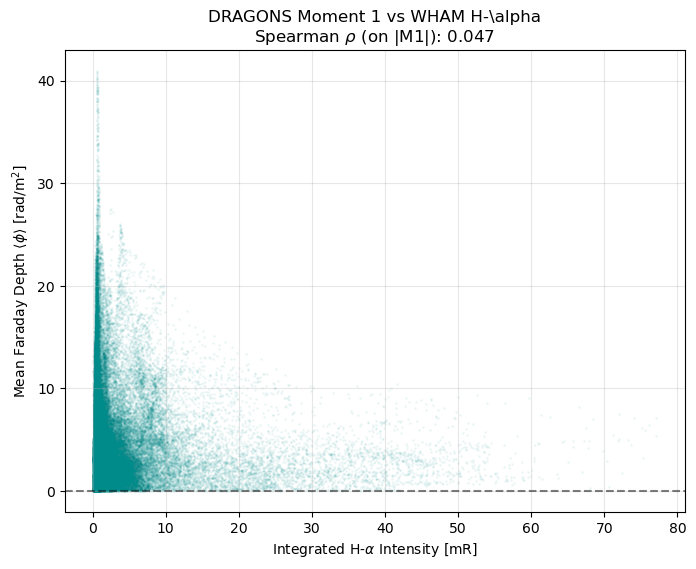

In [38]:
import numpy as np
from scipy.stats import spearmanr

leakmask = (MoneDat != 0.0) 

validMask = (
    (whamSmoothed != hp.UNSEEN) & 
    (MoneDat != hp.UNSEEN) & 
    (~np.isnan(whamSmoothed)) & 
    (~np.isnan(MoneDat)) & 
    leakmask  # Removed the 'MoneDat > 0' filter so negative regions are kept
)

# Now cleanM1 safely contains both positive and negative lines of sight
cleanHa = whamSmoothed[validMask]
cleanM1 =      MoneDat[validMask]

# Compute the correlation on the absolute value
# Fixed the variable naming mismatch here
spearmanRes = spearmanr(cleanHa, np.abs(cleanM1))
absM1rho    = spearmanRes.statistic 
absM1pVal      = spearmanRes.pvalue

print("--- Corrected Absolute Moment 1 Test ---")
print(f"Spearman rho: {absM1rho:.4f}")
print(f"p-value:      {absM1pVal}")

plt.figure(figsize=(8,6))
plt.scatter(cleanHa, np.abs(cleanM1), alpha=0.05, c='darkcyan', s=1)
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.xlabel(r"Integrated H-$\alpha$ Intensity [mR]")
plt.ylabel(r"Mean Faraday Depth $\langle\phi\rangle$ [rad/m$^2$]")
plt.title(f"DRAGONS Moment 1 vs WHAM H-\\alpha\nSpearman $\\rho$ (on |M1|): {absM1rho:.3f}")
plt.grid(True, alpha=0.3)
plt.show()

Spearman rho: -0.06986072339597181
p-value:      2.0180754241879037e-139


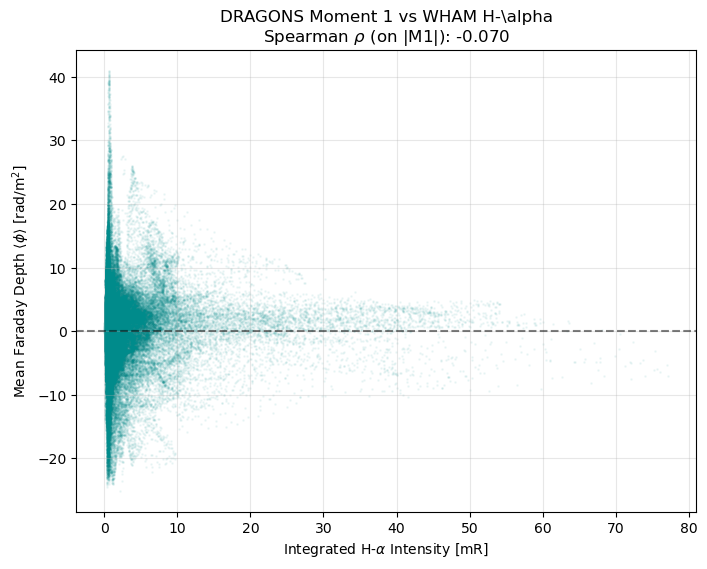

In [39]:
leakmask = (MoneDat != 0.0) 

validMask = (
    (whamSmoothed != hp.UNSEEN) & 
    (MoneDat != hp.UNSEEN) & 
    (~np.isnan(whamSmoothed)) & 
    (~np.isnan(MoneDat)) & 
    # (MoneDat > 0) & 
    leakmask
)

cleanHa = whamSmoothed[validMask]
cleanM1 =      MoneDat[validMask]

spearmanResult = spearmanr(cleanM1, cleanHa)
M1rho      = spearmanResult.statistic 
M1pVal       = spearmanResult.pvalue

print(f"Spearman rho: {M1rho}")
print(f"p-value:      {M1pVal}")

plt.figure(figsize=(8,6))
plt.scatter(cleanHa, cleanM1, alpha=0.05, c='darkcyan', s=1)
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.xlabel(r"Integrated H-$\alpha$ Intensity [mR]")
plt.ylabel(r"Mean Faraday Depth $\langle\phi\rangle$ [rad/m$^2$]")
plt.title(f"DRAGONS Moment 1 vs WHAM H-\\alpha\nSpearman $\\rho$ (on |M1|): {M1rho:.3f}")
plt.grid(True, alpha=0.3)
plt.show()

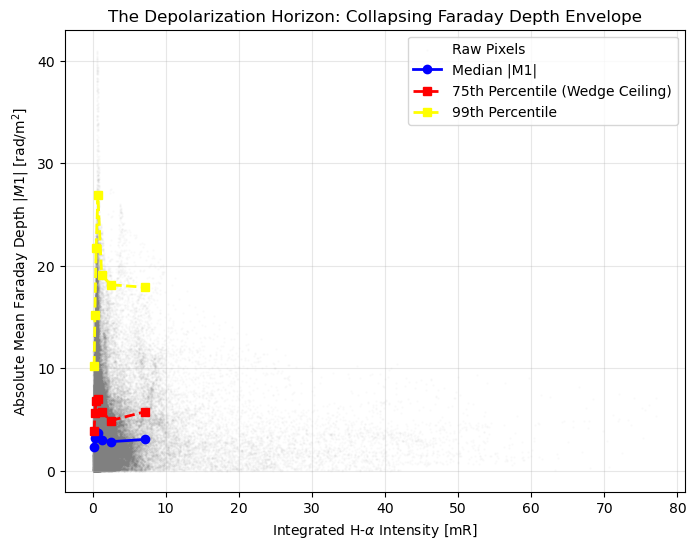

In [40]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define your 6 distinct H-alpha intensity bins based on your earlier validUniquePeaks layout
# You can use np.logspace or np.percentile to slice the gas density evenly
haBins = np.percentile(cleanHa, np.linspace(0, 100, 8))

binnedHaCenters = []
binnedM1UpperQuantile = [] # Tracks the top 75% edge of the funnel
binnedM1Medians = []
binnedM1UpperLim = []
for i in range(len(haBins)-1):
    binMask = (cleanHa >= haBins[i]) & (cleanHa < haBins[i+1])
    m1InBin = np.abs(cleanM1)[binMask]
    haInBin = cleanHa[binMask]
    
    if len(m1InBin) > 0:
        binnedHaCenters.append(np.median(haInBin))
        binnedM1Medians.append(np.median(m1InBin))
        # Track the 75th percentile to mathematically map the collapsing "ceiling" of the wedge
        binnedM1UpperQuantile.append(np.percentile(m1InBin, 75))
        binnedM1UpperLim.append(np.percentile(m1InBin, 99))
        
# 2. Plot the structural envelope of the funnel
plt.figure(figsize=(8,6))
plt.scatter(cleanHa, np.abs(cleanM1), alpha=0.02, c='gray', s=1, label='Raw Pixels')
plt.plot(binnedHaCenters, binnedM1Medians, 'o-', color='blue', linewidth=2, label='Median |M1|')
plt.plot(binnedHaCenters, binnedM1UpperQuantile, 's--', color='red', linewidth=2, label='75th Percentile (Wedge Ceiling)')
plt.plot(binnedHaCenters, binnedM1UpperLim, 's--', color = 'yellow', linewidth=2, label='99th Percentile')
plt.xlabel(r"Integrated H-$\alpha$ Intensity [mR]")
plt.ylabel(r"Absolute Mean Faraday Depth $|M1|$ [rad/m$^2$]")
plt.title("The Depolarization Horizon: Collapsing Faraday Depth Envelope")
plt.legend()

plt.grid(True, alpha=0.3)
plt.show()


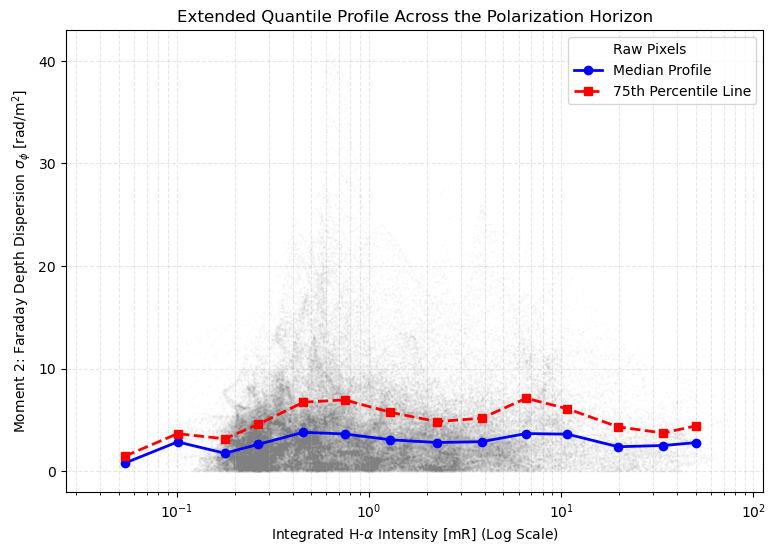

In [41]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Strip out zero or negative values to prevent math errors on a log axis
positiveHaMask = (cleanHa > 0)
filteredHa = cleanHa[positiveHaMask]
filteredM1 = np.abs(cleanM1)[positiveHaMask]  # Swap with cleanM0 or np.abs(cleanM1) depending on the map

# 2. Create 15 log-spaced bins running from your minimum to maximum H-alpha values
# This forces the bins to cover the entire horizontal span of the scatter plot
haBins = np.logspace(np.log10(np.min(filteredHa)), np.log10(np.max(filteredHa)), 15)

binnedHaCenters = []
binnedM1Medians = []
binnedM1UpperQuantile = []

# 3. Process the bins
for i in range(len(haBins)-1):
    binMask = (filteredHa >= haBins[i]) & (filteredHa < haBins[i+1])
    m2InBin = filteredM1[binMask]
    haInBin = filteredHa[binMask]
    
    # Only plot the bin if it contains a statistically meaningful number of independent pixels
    # Setting a minimum threshold (e.g., 20 pixels) prevents noisy edge effects
    if len(m1InBin) > 20:
        binnedHaCenters.append(np.median(haInBin))
        binnedM1Medians.append(np.median(m2InBin))
        binnedM1UpperQuantile.append(np.percentile(m2InBin, 75))

# 4. Plot the full extension
plt.figure(figsize=(9,6))
plt.scatter(filteredHa, filteredM1, alpha=0.02, c='gray', s=1, label='Raw Pixels')

plt.plot(binnedHaCenters, binnedM1Medians, 'o-', color='blue', linewidth=2, label='Median Profile')
plt.plot(binnedHaCenters, binnedM1UpperQuantile, 's--', color='red', linewidth=2, label='75th Percentile Line')

# CRUCIAL: Set the X-axis to a log scale so you can inspect the high-density behavior
plt.xscale('log')
plt.xlabel(r"Integrated H-$\alpha$ Intensity [mR] (Log Scale)")
plt.ylabel("Moment 2: Faraday Depth Dispersion $\sigma_\phi$ [rad/m$^2$]")
plt.title("Extended Quantile Profile Across the Polarization Horizon")
plt.legend()
plt.grid(True, which="both", linestyle='--', alpha=0.3)


In [42]:
fn = '~/ResearchSummer26/DRAGONS/DRAGONS_faraday_depth_cubes/faraday_synthesis/dragons_m2_gal.hpx.fits'
MtwoHdr = fits.getheader(fn) 
MtwoDat = fits.getdata(fn)
MtwoHdr

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -64 / array data type                                
NAXIS   =                    1 / number of array dimensions                     
NAXIS1  =               196608                                                  
PIXTYPE = 'HEALPIX '           / HEALPIX pixelisation                           
ORDERING= 'RING    '           / Pixel ordering scheme, either RING or NESTED   
NSIDE   =                  128 / Resolution parameter of HEALPIX                
INDXSCHM= 'IMPLICIT'           / Indexing: IMPLICIT or EXPLICIT                 
OBJECT  = 'FULLSKY '           / Sky coverage, either FULLSKY or PARTIAL        
BUNIT   = 'rad/m^2 '                                                            
DATE    = '2025-09-15'                                                          
INSTRUME= 'DRAO-15 '                                                            

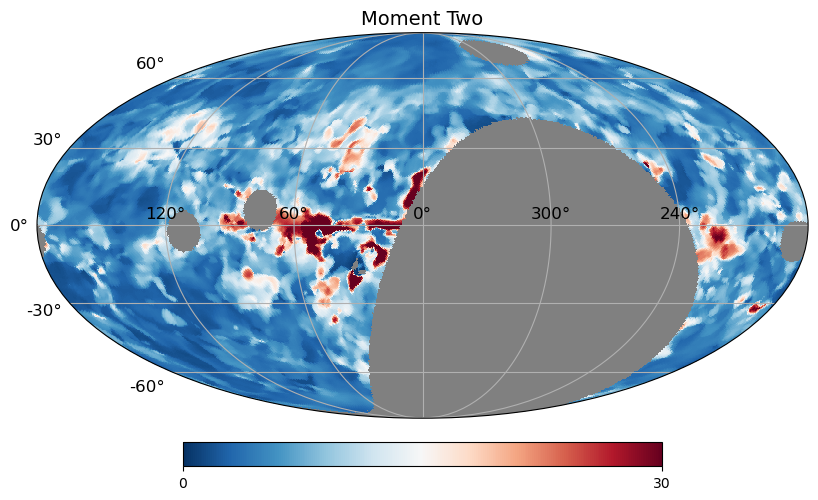

In [43]:
projview(
    MtwoDat, 
    projection_type = 'mollweide', 
    graticule = True, 
    graticule_labels=True, 
    cb_orientation = 'horizontal', 
    cmap = 'RdBu_r', 
    title = 'Moment Two',\
    min = 0, 
    max = 30
)

M0 rho: -0.23484748811586253 | M0 pVal: 0.0
M1 rho: -0.06986072339597181 | M1 pVal: 2.0180754241879037e-139
M2 rho:  0.30684390862181626 | M2 pVal: 0.0


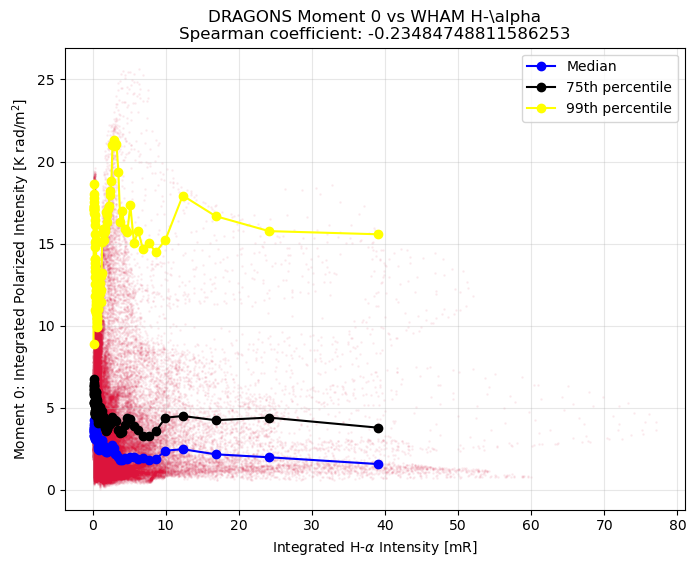

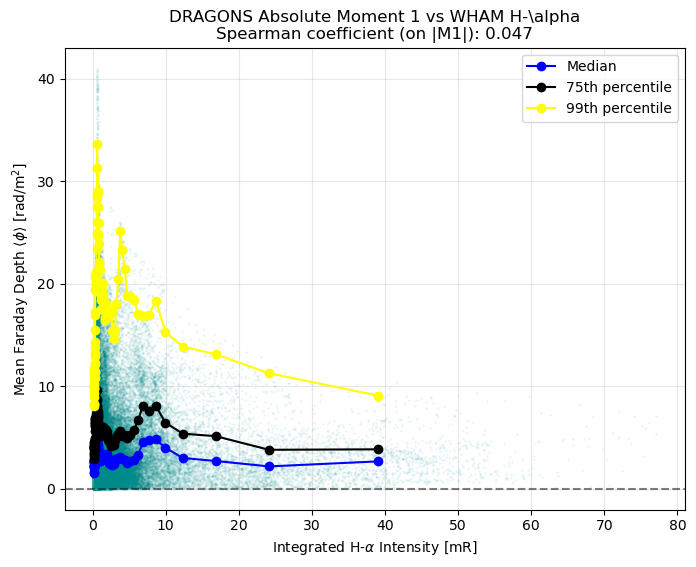

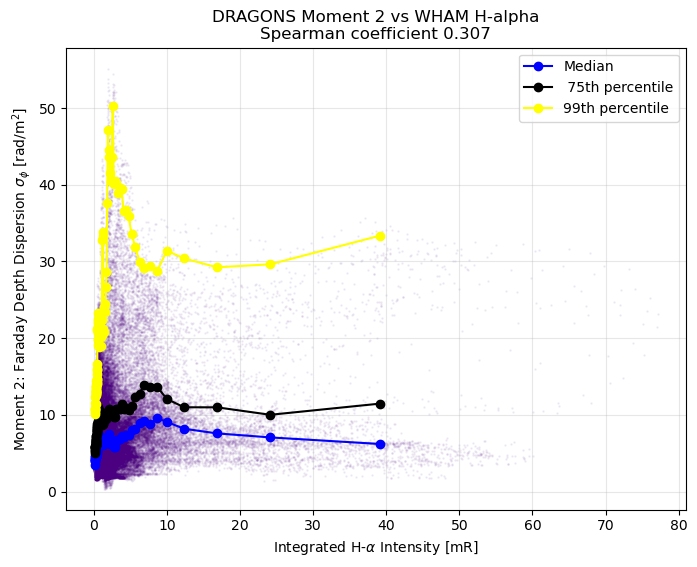

In [44]:
validMaskM0 = (
    (whamSmoothed != hp.UNSEEN) & (MzeroDat != hp.UNSEEN) & 
    (~np.isnan(whamSmoothed)) & (~np.isnan(MzeroDat)) & (MzeroDat != 0.0) & (whamSmoothed <= 100)
)
validMask = (
    (whamSmoothed != hp.UNSEEN) & (MoneDat != hp.UNSEEN) & 
    (~np.isnan(whamSmoothed)) & (~np.isnan(MoneDat)) & (whamSmoothed <=100) & 
    leakmask
)
validMaskM2 = (
    (whamSmoothed != hp.UNSEEN) & (MtwoDat != hp.UNSEEN) & 
    (~np.isnan(whamSmoothed)) & (~np.isnan(MtwoDat)) & (MtwoDat != 0.0) & (whamSmoothed <= 100)
)

haBins = np.percentile(cleanHa, np.linspace(0, 100, 100))


cleanHaM0 = whamSmoothed[validMaskM0] 
cleanM0 = MzeroDat[validMaskM0]

cleanHaM2 = whamSmoothed[validMaskM2]
cleanM2 = MtwoDat[validMaskM2]


statsM0 = spearmanr(cleanHaM0, cleanM0)
statsM2 = spearmanr(cleanHaM2, cleanM2) 


M0rho = statsM0.statistic 
M0pVal = statsM0.pvalue


M2rho = statsM2.statistic 
M2pVal = statsM2.pvalue 


print(f"M0 rho: {M0rho} | M0 pVal: {M0pVal}")
print(f"M1 rho: {M1rho} | M1 pVal: {M1pVal}")
print(f"M2 rho:  {M2rho} | M2 pVal: {M2pVal}")


binnedM0Medians =[]
binnedM0UpperLim =[]
binnedM0UpperQuantile =[]
binnedHaM0Centers = []
for i in range(len(haBins)-1):
    binMask = (cleanHa >= haBins[i]) & (cleanHa < haBins[i+1])
    m0InBin = np.abs(cleanM0)[binMask]
    haInBin = cleanHa[binMask]
    if len(m0InBin) > 0:
        binnedHaM0Centers.append(np.median(haInBin))
        binnedM0Medians.append(np.median(m0InBin))
        # Track the 75th percentile to mathematically map the collapsing "ceiling" of the wedge
        binnedM0UpperQuantile.append(np.percentile(m0InBin, 75))
        binnedM0UpperLim.append(np.percentile(m0InBin, 99))


binnedM1Medians =[] 
binnedM1UpperQuantile = [] 
binnedM1UpperLim =[]   
binnedHaM1Centers = []
for i in range(len(haBins)-1):
    binMask = (cleanHa >= haBins[i]) & (cleanHa < haBins[i+1])
    m1InBin = np.abs(cleanM1)[binMask]
    haInBin = cleanHa[binMask] 
    if len(m1InBin) > 0:
        binnedHaM1Centers.append(np.median(haInBin))
        binnedM1Medians.append(np.median(m1InBin))
        # Track the 75th percentile to mathematically map the collapsing "ceiling" of the wedge
        binnedM1UpperQuantile.append(np.percentile(m1InBin, 75))
        binnedM1UpperLim.append(np.percentile(m1InBin, 99))


binnedM2Medians =[]
binnedM2UpperQuantile = []
binnedM2UpperLim =[] 
binnedHaM2Centers =[]

for i in range(len(haBins)-1):
    binMask = (cleanHa >= haBins[i]) & (cleanHa < haBins[i+1])
    m2InBin = np.abs(cleanM2)[binMask]
    haInBin = cleanHa[binMask]
    if len(m2InBin) > 0:
        binnedHaM2Centers.append(np.median(haInBin))
        binnedM2Medians.append(np.median(m2InBin))
        # Track the 75th percentile to mathematically map the collapsing "ceiling" of the wedge
        binnedM2UpperQuantile.append(np.percentile(m2InBin, 75))
        binnedM2UpperLim.append(np.percentile(m2InBin, 99))




    
plt.figure(figsize=(8,6))
plt.scatter(cleanHaM0, cleanM0, alpha=0.05, c='crimson', s=1)
plt.plot(binnedHaM0Centers, binnedM0Medians, 'o-', color = 'blue', label = 'Median')
plt.plot(binnedHaM0Centers, binnedM0UpperQuantile, 'o-', color = 'black', label = '75th percentile')
plt.plot(binnedHaM0Centers, binnedM0UpperLim, 'o-', color = 'yellow', label = '99th percentile') 
plt.xlabel(r"Integrated H-$\alpha$ Intensity [mR]")
plt.ylabel("Moment 0: Integrated Polarized Intensity [K rad/m$^2$]")
plt.title(f"DRAGONS Moment 0 vs WHAM H-\\alpha\nSpearman coefficient: {statsM0.statistic}")
plt.grid(True, alpha=0.3)
plt.legend()
plt.savefig('FD_mom_zero_vs_Halpha.png', dpi=300, bbox_inches='tight')
plt.show()


plt.figure(figsize=(8,6))
plt.scatter(cleanHa, np.abs(cleanM1), alpha=0.05, c='darkcyan', s=1)
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.plot(binnedHaM1Centers, binnedM1Medians, 'o-', color = 'blue', label = 'Median')
plt.plot(binnedHaM1Centers, binnedM1UpperQuantile, 'o-', color = 'black', label = '75th percentile')
plt.plot(binnedHaM1Centers, binnedM1UpperLim, 'o-', color = 'yellow', label = '99th percentile')
plt.xlabel(r"Integrated H-$\alpha$ Intensity [mR]")
plt.ylabel(r"Mean Faraday Depth $\langle\phi\rangle$ [rad/m$^2$]")
plt.title(f"DRAGONS Absolute Moment 1 vs WHAM H-\\alpha\nSpearman coefficient (on |M1|): {rhoValue:.3f}")
plt.grid(True, alpha=0.3)
plt.legend()
plt.savefig('FD_mom_one_vs_Halpha.png', dpi=300, bbox_inches='tight')
plt.show()


plt.figure(figsize=(8,6))
plt.scatter(cleanHaM2, cleanM2, alpha=0.05, c='indigo', s=1)
plt.plot(binnedHaM2Centers, binnedM2Medians, 'o-', color = 'blue', label = 'Median')
plt.plot(binnedHaM2Centers, binnedM2UpperQuantile, 'o-', color = 'black', label = ' 75th percentile') 
plt.plot(binnedHaM2Centers, binnedM2UpperLim, 'o-', color = 'yellow', label = '99th percentile') 
plt.xlabel(r"Integrated H-$\alpha$ Intensity [mR]")
plt.ylabel(r"Moment 2: Faraday Depth Dispersion $\sigma_\phi$ [rad/m$^2$]")
plt.title(f"DRAGONS Moment 2 vs WHAM H-alpha\nSpearman coefficient {statsM2.statistic:.3f}")
plt.grid(True, alpha=0.3)
plt.legend()
plt.savefig('FD_mom_two_vs_Halpha.png', dpi=300, bbox_inches='tight')
plt.show()

In [45]:
from scipy.stats import ks_2samp

# 1. Isolate pixels just past the threshold (e.g., 5 to 10 mR)
horizonZone1 = cleanM0[(cleanHa >= 5.0) & (cleanHa < 10.0)]

# 2. Isolate pixels deep past the threshold (e.g., 15 to 20 mR)
horizonZone2 = cleanM0[(cleanHa >= 15.0) & (cleanHa <= 20.0)]

# 3. Run the K-S Test
ksStat, pValueKs = ks_2samp(horizonZone1, horizonZone2)

print("--- Horizon Opaque Permanence Test ---")
print(f"K-S Statistic: {ksStat:.4f}")
print(f"p-value:       {pValueKs:.4f}")

if pValueKs > 0.05:
    print("Conclusion: The distributions are identical. The polarization profile has officially hit a flat, unmoving horizon state.")
else:
    print("Conclusion: The distribution is still changing slightly.")


--- Horizon Opaque Permanence Test ---
K-S Statistic: 0.1171
p-value:       0.0000
Conclusion: The distribution is still changing slightly.


# Make it simple, look for a relationship between polarized intensity and H-alpha intensity 

In [ ]:
fn = '~/ResearchSummer26/DRAGONS/DRAGONS_FREQUENCY_HEALPIX_CUBES/dragons_freqK_gal_q.hpx.fits'
qHdr = fits.getheader(fn)
qDat = fits.getdata(fn) 
qHdr

In [ ]:
fn = '~/ResearchSummer26/DRAGONS/DRAGONS_FREQUENCY_HEALPIX_CUBES/dragons_freqK_gal_u.hpx.fits'
uHdr = fits.getheader(fn)
uDat = fits.getdata(fn) 
uHdr

In [ ]:
pIDat = np.sqrt(uDat**2 + qDat**2)

In [ ]:
#integrating PI 
integratedPI = np.nansum(pIDat[:,:], axis = 0)


In [ ]:
projview(
    integratedPI,
    projection_type = 'mollweide', 
    graticule = True, 
    graticule_labels=True, 
    cb_orientation = 'horizontal', 
    cmap = 'magma', 
     min = 0, 
     max = 500, 
    unit = 'K', 
    title = 'Polarized Intensity',
)

In [ ]:
from scipy.stats import pearsonr
pIHaSpearman = spearmanr(whamHealpix, integratedPI)
pIHaRho = pIHaSpearman.statistic
pIHaP = pIHaSpearman.pvalue
pIHaPearson = pearsonr(whamHealpix, integratedPI) 
pIHaR = pIHaPearson.statistic
pIHaPP = pIHaPearson.pvalue
print(f"Polarized Intensity v H-alpha intensity pearson coefficient: {pIHaR:.4f} \nP-value: {pIHaPP:4e}")

print(f"Polarized Intensity v H-alpha intensity spearman coefficient: {pIHaRho:.4f} \n P-value: {pIHaP:.4e}")

In [ ]:
ydat = integratedPI 
xdat = whamHealpix 
plt.scatter(xdat, ydat, s = 0.5, color = 'darkcyan', alpha = 0.2) 
plt.xlim(-1, 60)
plt.ylim(0, 2000) 
plt.grid(alpha = 0.5)

# Going to make moment maps of h-alpha data now to compare to the moments of the faraday depth cube 

In [46]:
whamHpx = whamHealpix

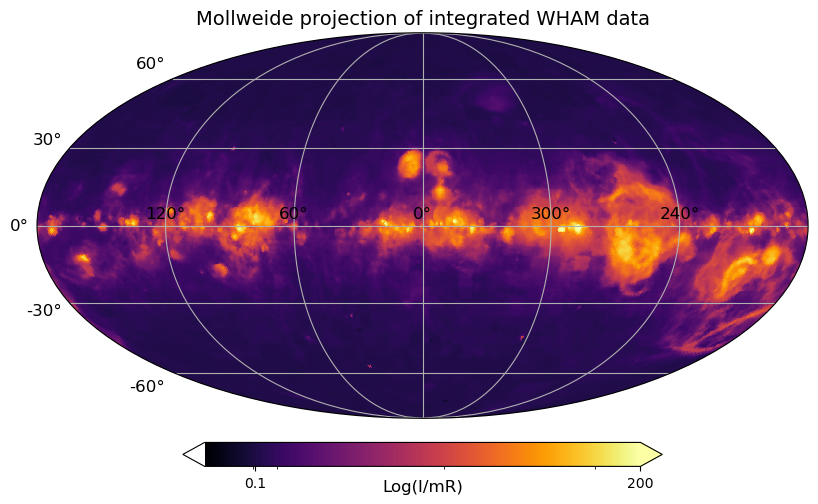

In [47]:
projview(
    whamHpx, 
    projection_type = 'mollweide', 
    graticule = True, 
    graticule_labels=True, 
    cb_orientation = 'horizontal', 
    cmap = 'inferno', 
    min = 0.1, 
    max = 200, 
    unit = 'Log(I/mR)', 
    title = 'Mollweide projection of integrated WHAM data',
    norm = SymLogNorm(vmin = -2, vmax = 200, linthresh = 7)
)

In [48]:
#need wham in regular fits to be able to use spectral cube 
fn = '~/ResearchSummer26/WHAM/wham-ss-DR1-v161116-170912-grid.fits'
whamHdr = fits.getheader(fn) 
whamDat = fits.getdata(fn)

In [49]:
from spectral_cube import SpectralCube
whamHdr

 [astropy.io.fits.verify]


SIMPLE  =                    T /  Written by IDL:  Tue Sep 12 13:28:51 2017     
BITPIX  =                  -32 / Real*4 (floating point)                        
NAXIS   =                    3 /                                                
NAXIS1  =                 1440 /                                                
NAXIS2  =                  720 /                                                
NAXIS3  =                  162 /                                                
EXTEND  =                    T / Extensions may be present                      
DATE    = '2017-09-12'         /                                                
TAG     = 'DR1     '           / General release tag                            
VERSION = '161116  '           / Generated from wham-ss-161116.sav              
OBJECT  = 'WHAM Sky Survey - Release DR1 (161116)' /                            
RESTWAV =          6.56300E-07 / Rest wavelength of H-alpha [m]                 
BSCALE  =              1.000

In [50]:
cube = SpectralCube.read(fn)
whamMomZero = cube.moment(order=0)
whamMomOne  = cube.moment(order=1) 
whamMomTwo  = cube.moment(order=2)

 [astropy.io.fits.verify]


In [51]:
targetNside = 128,
coordsys = 'G'
whamMomTwoHpx, footprint = reproject_to_healpix(
    (whamMomTwo, wcs2d), 
    coord_system_out = coordsys, 
    nside=targetNside, 
    order = 'bilinear'
)
whamMomOneHpx, footprint = reproject_to_healpix(
    (whamMomOne, wcs2d), 
    coord_system_out = coordsys, 
    nside=targetNside, 
    order = 'bilinear'
)

In [52]:
whamHdr

SIMPLE  =                    T /  Written by IDL:  Tue Sep 12 13:28:51 2017     
BITPIX  =                  -32 / Real*4 (floating point)                        
NAXIS   =                    3 /                                                
NAXIS1  =                 1440 /                                                
NAXIS2  =                  720 /                                                
NAXIS3  =                  162 /                                                
EXTEND  =                    T / Extensions may be present                      
DATE    = '2017-09-12'         /                                                
TAG     = 'DR1     '           / General release tag                            
VERSION = '161116  '           / Generated from wham-ss-161116.sav              
OBJECT  = 'WHAM Sky Survey - Release DR1 (161116)' /                            
RESTWAV =          6.56300E-07 / Rest wavelength of H-alpha [m]                 
BSCALE  =              1.000

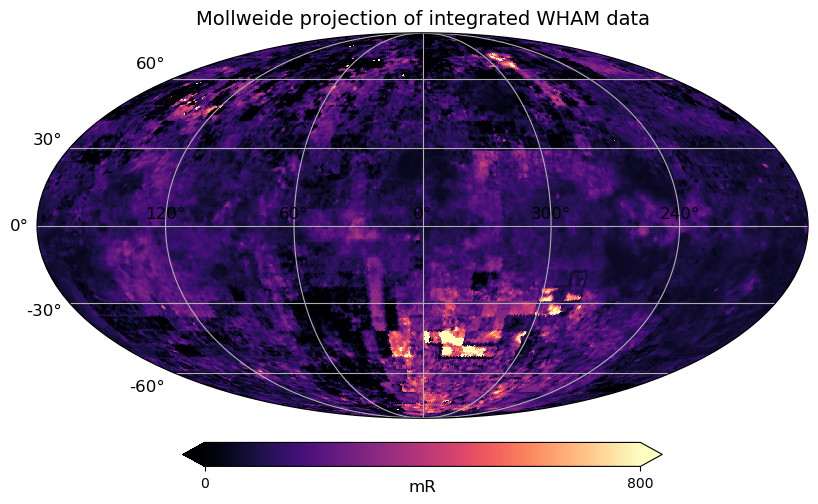

In [53]:
projview(
    whamMomTwoHpx, 
    projection_type = 'mollweide', 
    graticule = True, 
    graticule_labels=True, 
    cb_orientation = 'horizontal', 
    cmap = 'magma', 
    min = 0, 
    max = 800, 
    unit = 'mR', 
    title = 'Mollweide projection of integrated WHAM data',
    # norm = SymLogNorm(vmin = -5, vmax = 5000, linthresh = 7)
)

In [54]:
MtwoDat.shape, whamMomTwoHpx.shape, whamMomOneHpx.shape

((196608,), (196608,), (196608,))

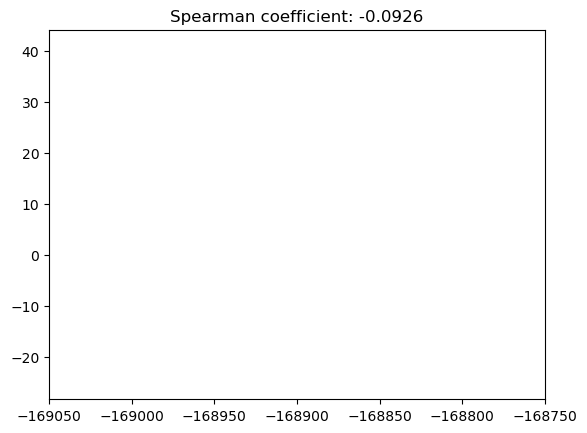

Text(0.5, 1.0, 'Spearman coefficient: -0.026091')

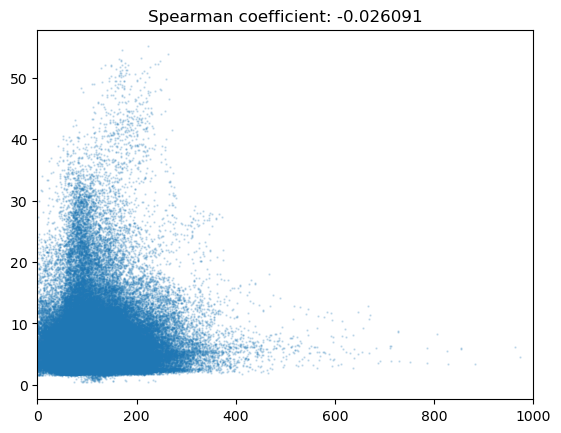

In [55]:










validMaskM1 = (
    (whamMomOneHpx != hp.UNSEEN) & (MoneDat != hp.UNSEEN) & 
    (~np.isnan(whamMomOneHpx)) & (~np.isnan(MoneDat)) &
    leakmask 
)
validWhamMomOne = np.abs(whamMomOneHpx[validMaskM1]) 
cleanMoneDat = MoneDat[validMaskM1]
MomOneSpearman = spearmanr(validWhamMomOne, cleanMoneDat) 
MomOneRho      = MomOneSpearman.statistic
plt.title(f"Spearman coefficient: {MomOneRho:.4f}")
plt.scatter(validWhamMomOne, cleanMoneDat, s = 0.5, alpha = 0.2, color = 'darkcyan')
plt.xlim(-169050, -168750)
plt.show()



validMaskM2 = (
    (whamMomTwoHpx != hp.UNSEEN) & (MtwoDat != hp.UNSEEN) & 
    (~np.isnan(whamMomTwoHpx)) & (~np.isnan(MtwoDat)) & (MtwoDat != 0.0) & (MtwoDat >=0) & (whamMomTwoHpx >= 0) )

validWhamMomTwo = whamMomTwoHpx[validMaskM2]
cleanM2 = MtwoDat[validMaskM2]
MomTwoSpearman = spearmanr(validWhamMomTwo, cleanM2) 
MomTwoRho = MomTwoSpearman.statistic 
plt.scatter(validWhamMomTwo, cleanM2, s = 0.5, alpha = 0.2)
plt.xlim(0, 1e3)
plt.title(f"Spearman coefficient: {MomTwoRho:4f}")